In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy


from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [2]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [3]:
def correlation_function(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

### dlogk=0.1

In [9]:
r = np.arange(0.1,10,0.1)
logk = np.arange(-1.5,1.5,0.1)
ks = 10**logk
pk = Plin(ks)

xi = correlation_function(ks,pk,r)

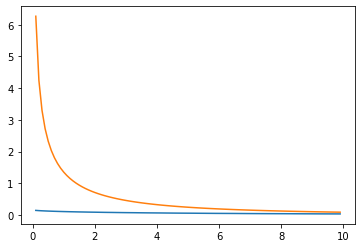

In [10]:
plt.plot(r, xi)
plt.plot(r, cf_lin(r))

### Linear bins in k

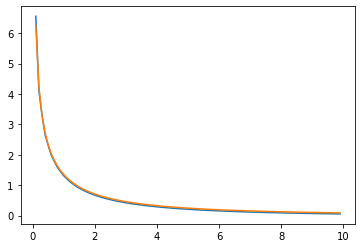

In [23]:
r = np.arange(0.1,10,0.1)
ks = np.linspace(10**-1.5, 10**1.5, 100)
pk = Plin(ks)

xi = correlation_function(ks,pk,r)

plt.plot(r, xi)
plt.plot(r, cf_lin(r))

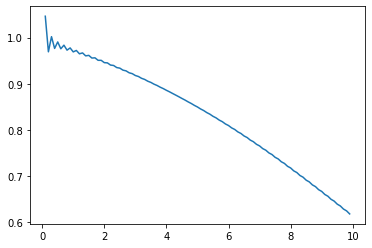

In [24]:
plt.plot(r, xi/cf_lin(r))

### Smaller bins in k

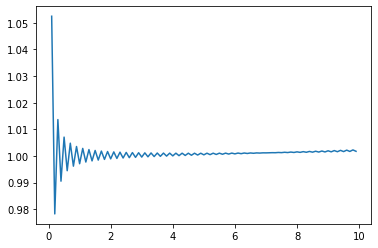

In [25]:
r = np.arange(0.1,10,0.1)
ks = np.linspace(10**-1.5, 10**1.5, 1000)
pk = Plin(ks)

xi = correlation_function(ks,pk,r)

plt.plot(r, xi/cf_lin(r))

### Smaller r

small r not as well produced

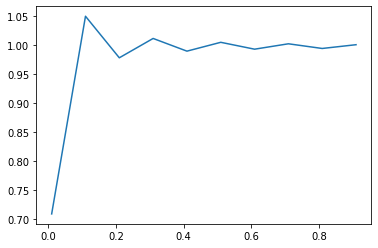

In [36]:
r = np.arange(0.01,1,0.1)
ks = np.linspace(10**-1.5, 10**1.5, 100000)
pk = Plin(ks)

xi = correlation_function(ks,pk,r)

plt.plot(r, xi/cf_lin(r))

Try changing k range

In [50]:
r = np.arange(0.01,0.1,0.01)
ks = np.linspace(10**-1.5, 10**3, int(1e6))
pk = Plin(ks)

xi = correlation_function(ks,pk,r)

plt.plot(r, xi/cf_lin(r))

KeyboardInterrupt: 

### Test kernel

In [26]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [27]:
def kernel_new(ks, xi, pk, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    xi = correlation_function(ks, pk,r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [29]:
kern =kernel_new(ks, xi, pk)

(-10.0, 5.0)

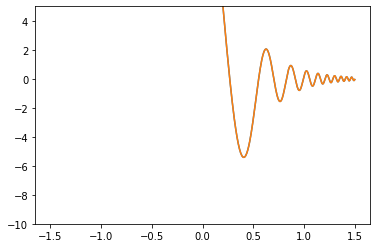

In [31]:
plt.plot(np.log10(ks),kern)
plt.plot(np.log10(ks),kernel_lin(ks))
plt.ylim(-10,5)

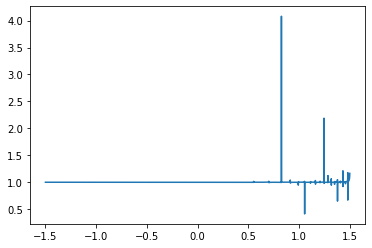

In [33]:
plt.plot(np.log10(ks),kern/kernel_lin(ks))
#plt.ylim(-10,5)